# MERRA-2 Virtualizing

In [52]:
# load external packages
import os
import pandas as pd
import xarray as xr
from pathlib import Path
import earthaccess
import ray
from tqdm import tqdm
from huggingface_hub import login, HfApi
import logging
import sys

Load modules from my `artools` package. Basically just a package specific to my ARs.

In [53]:
# load artools
import artools
from artools.loading_utils import load_ais, load_cell_areas, EarthdataGatekeeper, load_catalog
from artools.display_utils import display_catalog
from artools.attribute_utils import *
from artools.compute_attributes_streaming import *

In [3]:
earthaccess.login()
login()

In [5]:
# load the catalog
storms = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
# take only those that are landfalling
storms = storms[storms.is_landfalling]
# take a smaller subset for now
storms = storms.iloc[0:100]
# a compute start and end dates for each storm
storms['start_date'] = storms['data_array'].apply(add_start_date)
storms['end_date'] = storms['data_array'].apply(add_end_date)

In [7]:
ais_mask = load_ais()
cell_areas = load_cell_areas()

We need MERRA-2 data from the start date of the first storm in the list of ARs, to the end date of the last storm. Let's virtualize all of this data at once, and then call it up as needed for each storm.

In [8]:
first = storms.start_date.min()
last = storms.end_date.max()

In [ ]:
first

In [ ]:
last

Our MERRA-2 dataset of interest is stored as daily granules (netcdf4 files), each of which is hourly. We'll first search for all the granules we need.

In [9]:
data_doi = '10.5067/3Z173KIE2TPD'
# stream the data only between those two dates
granule_lst = earthaccess.search_data(doi=data_doi, 
                                  temporal=(f'{first.year}-{first.month}-{first.day}', 
                                            f'{last.year}-{last.month}-{last.day}'))

/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/search.py:955: FutureWarning: As of version 1.0, `DataCollection.concept_id` will be accessed as an attribute; e.g. use `DataCollection.concept_id` **not** `DataCollection.concept_id()`
  concept_id = collection[0].concept_id()
/srv/conda/envs/notebook/lib/python3.12/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


Next, virtualize the dataset

In [47]:
%%time
vds = earthaccess.virtualize(granule_lst, access='direct', concat_dim='time')

CPU times: user 2min 29s, sys: 5.39 s, total: 2min 35s
Wall time: 2min 30s


Next, we only need a few of the 24 variables of the full dataset, so let's just grab those DataArrays. Also, let's store this virtualized data as parquet. Note, to run the below, you need to pip install fastparquet, and also make sure your version of pandas is strictly below 3.0.

In [12]:
subset_vds = vds[['T2M', 'TQV']]
subset_vds.virtualize.to_kerchunk("test_subset.parquet", format="parquet")

Authenticate with S3 so you can access data stored in the buckets (otherwise, you'll get a credentialling error if you attempt to just start using xarray operations). The code in this cell is taken from [here](https://gist.github.com/betolink/82f6dd6f2a952dc03edc19bd6dee12ae).

In [20]:
import fsspec
import zarr

daac_fs = earthaccess.get_s3_filesystem(daac='GES_DISC')

fs = fsspec.filesystem("reference",
                       fo='test_subset.parquet',
                       remote_protocol="s3",
                       asynchronous=True,
                       remote_options={"asynchronous": True, **daac_fs.storage_options}
                      )

store = zarr.storage.FsspecStore(fs, read_only=True)
ds = xr.open_zarr(store, consolidated=False)
ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T2M' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'TQV' has multiple fill values {np.float64(999999986991104.0), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 42GB
Dimensions:  (time: 12480, lat: 361, lon: 576)
Coordinates:
  * time     (time) datetime64[ns] 100kB 1980-01-02 ... 1981-06-04T23:00:00
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
Data variables:
    T2M      (time, lat, lon) float64 21GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    TQV      (time, lat, lon) float64 21GB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
Attributes: (12/23)
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    Format:                            NetCDF-4/HDF-5
    SpatialCoverage:                   global
    VersionID:                         5.12.4
    ...                                ...
    DataResolution:                    0.5 x 0.625
    Source:                            CVS tag: GEOSadas-5_12_4
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/3Z173KIE2TPD
    RangeBeginningTime:                00:00:00.000000
    RangeEndingTime:                   23:00:00.000000

Now, you can treat this as a standard xarray object! For example, let's subset the data to the spatial parameters of our storm mask.

In [48]:
example = storms.iloc[0].data_array

In [49]:
%%time
var_da = ds.sel(time=example.time, lon=example.lon, lat=example.lat)

CPU times: user 3.18 s, sys: 89.5 ms, total: 3.27 s
Wall time: 3.27 s


It appears subsetting has rechunked our data? Now, we'll only be streaming just the data that correspond to our bounding box, instead of loading up huge chunks.

In [50]:
var_da

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 15, lat: 72, lon: 71)
Coordinates:
  * time     (time) datetime64[ns] 120B 1980-01-02 ... 1980-01-03T18:00:00
  * lat      (lat) float64 576B -74.5 -74.0 -73.5 -73.0 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 568B -119.4 -118.8 -118.1 ... -76.88 -76.25 -75.62
Data variables:
    T2M      (time, lat, lon) float64 613kB dask.array<chunksize=(1, 72, 71), meta=np.ndarray>
    TQV      (time, lat, lon) float64 613kB dask.array<chunksize=(1, 72, 71), meta=np.ndarray>
Attributes: (12/23)
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    Format:                            NetCDF-4/HDF-5
    SpatialCoverage:                   global
    VersionID:                         5.12.4
    ...                                ...
    DataResolution:                    0.5 x 0.625
    Source:                            CVS tag: GEOSadas-5_12_4
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/3Z173KIE2TPD
    RangeBeginningTime:                00:00:00.000000
    RangeEndingTime:                   23:00:00.000000

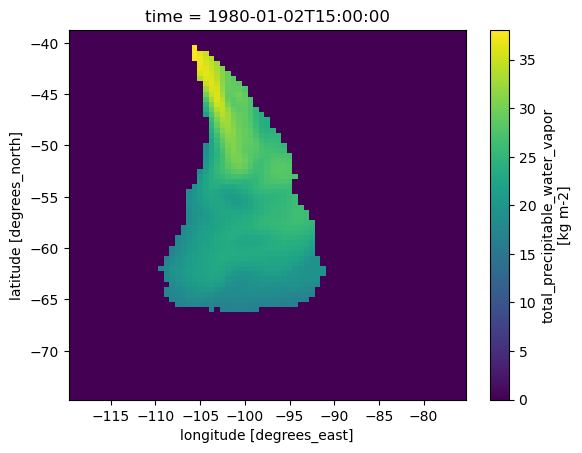

In [51]:
(var_da['TQV']*example).isel(time=5).plot()